# MLB Game Winner Model Development

Interactive training workflow for the GradientBoosting game-winner classifier.

**Pipeline:**
1. Pull historical game logs via pybaseball
2. Pull team batting/pitching stats per season
3. Build feature vectors for each game
4. Train a GradientBoosting classifier (home win = 1)
5. Evaluate and save model to `artifacts/`

## 1. Setup

In [634]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
pd.set_option('display.max_columns',None)

# Add model directory to path so local imports work
MODEL_DIR = os.path.abspath(".")
if MODEL_DIR not in sys.path:
    sys.path.insert(0, MODEL_DIR)

import pybaseball
pybaseball.cache.enable()

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from features import build_team_stats, game_features, feature_columns, TEAM_NAME_TO_ABB
from train import build_training_data, _get_game_logs

ARTIFACTS_DIR = os.path.join(MODEL_DIR, "artifacts")
MODEL_PATH = os.path.join(ARTIFACTS_DIR, "model.pkl")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f"Model dir: {MODEL_DIR}")
print(f"Artifacts: {ARTIFACTS_DIR}")



Model dir: /Users/nickchapman/pitch_predictor/backend/model
Artifacts: /Users/nickchapman/pitch_predictor/backend/model/artifacts


In [635]:
import mlflow
import mlflow.sklearn

MLFLOW_TRACKING_URI = os.path.join(MODEL_DIR, "mlruns")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("mlb-game-predictor-v1")
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")


MLflow tracking URI: /Users/nickchapman/pitch_predictor/backend/model/mlruns


## 2. Configure Training Years

In [636]:
# Adjust years as needed. 2020 is a shortened 60-game season.
YEARS = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

## 3. Inspect Team Stats (Single Season)

In [36]:
sample_year = 2024
stats = build_team_stats(sample_year)
print(f"{sample_year} team stats: {stats.shape}")
stats.sort_values('bat_avg')

2024 team stats: (30, 11)


,bat_avg,bat_obp,bat_slg,bat_bb_pct,bat_k_pct,pit_era,pit_whip,pit_k9,pit_bb9,pit_hr9,pit_fip
team_abb,,,,,,,,,,,
SEA,0.217401,0.303292,0.373467,0.095534,0.276587,3.421488,1.070624,8.885049,2.231405,1.115702,3.480917
CHW,0.221879,0.276754,0.340532,0.065298,0.234549,4.758781,1.462232,8.527199,4.355922,1.275723,4.499751
TBR,0.226109,0.296846,0.361977,0.082251,0.258601,3.677542,1.192588,9.014254,2.856509,1.248654,3.852613
LAA,0.229271,0.302145,0.371411,0.082179,0.238806,4.672532,1.373162,7.856092,3.878414,1.304622,4.531460
CIN,0.231852,0.306929,0.391908,0.084599,0.244966,4.083311,1.248872,8.725391,3.030247,1.232157,3.950889
DET,0.232874,0.297928,0.387780,0.079560,0.255264,3.603682,1.151368,8.042700,2.526720,0.952698,3.531092
OAK,0.234265,0.302437,0.395703,0.082121,0.248417,4.297154,1.325107,7.934777,3.304457,1.047091,3.950667
PIT,0.235075,0.304960,0.375612,0.083816,0.247764,4.080951,1.283046,8.696858,3.270875,1.031701,3.747891
TEX,0.237840,0.305199,0.380506,0.080332,0.212950,4.265173,1.258366,8.836642,3.009359,1.217527,3.898071


In [79]:
teams = stats.index.tolist()

## 4. Inspect Game Logs (Single Season)

In [4]:
logs = _get_game_logs(sample_year)
home_games = logs[logs["Home_Away"] == "Home"]
print(f"{sample_year} home games: {len(home_games)}")
print("W/L distribution:")
print(home_games["W/L"].str.strip().str.upper().value_counts())
home_games.head(5)

http://www.baseball-reference.com/teams/SEA/2024-schedule-scores.shtml


/Users/nickchapman/Library/Python/3.9/lib/python/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/NYM/2024-schedule-scores.shtml


/Users/nickchapman/Library/Python/3.9/lib/python/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/LAD/2024-schedule-scores.shtml


...

http://www.baseball-reference.com/teams/CLE/2024-schedule-scores.shtml


/Users/nickchapman/Library/Python/3.9/lib/python/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


http://www.baseball-reference.com/teams/DET/2024-schedule-scores.shtml
2024 home games: 2414
W/L distribution:
W/L
L       1152
W       1054
W-WO     208
Name: count, dtype: int64


/Users/nickchapman/Library/Python/3.9/lib/python/site-packages/pybaseball/team_results.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


,Date,Tm,Home_Away,Opp,W/L,R,RA,Inn,W-L,Rank,...,Win,Loss,Save,Time,D/N,Attendance,cLI,Streak,Orig. Scheduled,team_abb
0,"Thursday, Mar 28",SEA,Home,BOS,L,4.0,6.0,9.0,0-1,2.0,...,Bello,Castillo,Jansen,2:45,N,45337.0,.95,-1,None,SEA
1,"Friday, Mar 29",SEA,Home,BOS,W,1.0,0.0,9.0,1-1,2.0,...,Kirby,Pivetta,Muñoz,2:24,N,30013.0,.93,1,None,SEA
2,"Saturday, Mar 30",SEA,Home,BOS,W-wo,4.0,3.0,10.0,2-1,2.0,...,Saucedo,Rodríguez,None,2:46,N,32149.0,.96,2,None,SEA
3,"Sunday, Mar 31",SEA,Home,BOS,L,1.0,5.0,9.0,2-2,2.0,...,Whitlock,Miller,Slaten,2:32,D,29331.0,.99,-1,None,SEA
4,"Monday, Apr 1",SEA,Home,CLE,W,5.0,4.0,9.0,3-2,2.0,...,Hancock,McKenzie,Stanek,2:35,N,21322.0,.94,1,None,SEA


In [81]:
from pybaseball.datasources.bref import BRefSession
session = BRefSession()
_URL = "https://www.baseball-reference.com/teams/tgl.cgi?team={}&t={}&year={}"

def get_table(season: int, team: str, log_type: str) -> pd.DataFrame:
    t_param = "b" if log_type == "batting" else "p"
    content = session.get(_URL.format(team, t_param, season)).content
    soup = BeautifulSoup(content, "lxml")
    table_id = "players_standard_{}".format(log_type)
    table = soup.find("table", attrs=dict(id=table_id))
    if table is None:
        raise RuntimeError("Table with expected id not found on scraped page.")
    data = pd.read_html(StringIO(str(table)))[0]
    return data
def postprocess(data: pd.DataFrame) -> pd.DataFrame:
    #print(data.columns)
    data.drop([('Unnamed: 0_level_0', 'Rk')], axis=1, inplace=True)  # drop index column
    data = data.iloc[:-1]
    repl_dict = {
        "Gtm" : "Game",
        "Unnamed: 3_level_1": "Home",
        "#": "NumPlayers",
        "Opp. Starter (GmeSc)": "OppStart",
        "Pitchers Used (Rest-GameScore-Dec)": "PitchersUsed"
    }
    data = data.rename(columns= repl_dict).copy()
    data[('Unnamed: 3_level_0','Home')] = data[('Unnamed: 3_level_0','Home')].isnull()  # '@' if away, empty if home
    data = data[data[('Unnamed: 1_level_0','Game')] != 'Gtm'].copy()  # drop empty month rows
    data = data.apply(pd.to_numeric, errors="ignore")
    data[('Unnamed: 1_level_0','Game')] = data[('Unnamed: 1_level_0','Game')].astype(int)
    return data.reset_index(drop=True)


def team_game_logs(season: int, team: str, log_type: str="batting") -> pd.DataFrame:
    """
    Get Baseball Reference batting or pitching game logs for a team-season.

    :param season: year of logs
    :param team: team abbreviation
    :param log_type: "batting" (default) or "pitching"
    :return: pandas.DataFrame of game logs
    """
    if log_type not in ("batting", "pitching"):
        raise ValueError("`log_type` must be either 'batting' or 'pitching'.")
    data = get_table(season, team, log_type)
    data = postprocess(data)
    return data

In [84]:
game_logs_test.head()

,Game,Date,Home,Opp,Rslt,RS,RA,Inn,PA,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,BA,OBP,SLG,OPS,TB,GIDP,HBP,SH,SF,ROE,IBB,BAbip,LOB,NumPlayers,Player,T,GmSc
0,1,2024-03-28,False,SEA,W,6,4,9,40,38,6,11,2,1,2,6,3,1,2,7,0.289,0.325,0.553,0.878,21,0,0,0,0,0,0,0.310,7,10,Luis Castillo,R,42
1,2,2024-03-29,False,SEA,L,0,1,9,34,31,0,4,0,0,0,0,1,0,3,13,0.217,0.270,0.362,0.633,4,0,0,0,0,0,0,0.222,7,10,George Kirby,R,76
2,3,2024-03-30,False,SEA,L,3,4,10,39,36,3,7,2,0,0,3,0,1,3,13,0.210,0.265,0.324,0.589,9,0,0,0,0,0,1,0.304,7,12,Logan Gilbert,R,72
3,4,2024-03-31,False,SEA,W,5,1,9,38,35,5,10,0,0,2,5,0,1,3,8,0.229,0.285,0.357,0.642,16,0,0,0,0,0,0,0.320,6,10,Bryce Miller,R,43
4,5,2024-04-01,False,OAK,W,9,0,9,44,35,9,9,2,0,0,7,3,0,7,11,0.234,0.303,0.349,0.651,11,0,0,0,2,1,1,0.346,8,11,Joe Boyle,R,12


In [89]:
# failures = []
# for team in teams:
#     for year in YEARS:
#         for log_type in ['batting','pitching']:
#             try:
#                 game_logs_test = team_game_logs(season=year,team=team,log_type=log_type)
#                 game_logs_test.columns = game_logs_test.columns.droplevel()
#                 game_logs_test.to_parquet(f"{log_type}_{team}_{year}_logs.parquet")
#             except:
#                 print(f"{team} + {year} + {log_type} failed")
#                 failures.append([team, year, log_type])
                
        

/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")
/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")
/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")
/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore

OAK + 2025 + batting failed
OAK + 2025 + pitching failed
OAK + 2026 + batting failed
OAK + 2026 + pitching failed


/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")
/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")
/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")
/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore

In [95]:
# for each in failures:
#     year = each[1]
#     team = 'ATH'
#     log_type=each[2]
#     print(year, team, log_type)
#     game_logs_test = team_game_logs(season=year,team=team,log_type=log_type)
#     game_logs_test.columns = game_logs_test.columns.droplevel()
#     game_logs_test.to_parquet(f"{log_type}_{team}_{year}_logs.parquet")

2025 ATH batting


/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")


2025 ATH pitching


/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")


2026 ATH batting


/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")


2026 ATH pitching


/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/1069160815.py:29: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors="ignore")


## 5. Build Full Training Dataset

In [508]:
import glob

files = glob.glob("./artifacts/game_log_data/*.parquet")
def read_file(x):
    temp = pd.read_parquet(x)
    temp['season'] = x.split("/")[-1].split('_')[2]
    temp['log_type'] = x.split("/")[-1].split('_')[0]
    temp['team'] = x.split("/")[-1].split('_')[1].replace('ATH','OAK')
    return(temp)
    
game_logs = pd.concat([read_file(f) for f in files], ignore_index=True).reset_index(drop=True)

In [509]:
home_games_pitching = game_logs.query("(Home==True) & (log_type=='pitching')").copy()
away_games_pitching = game_logs.query("(Home==False) & (log_type=='pitching')").copy()

home_games_batting = game_logs.query("(Home==True) & (log_type=='batting')").copy()
away_games_batting = game_logs.query("(Home==False) & (log_type=='batting')").copy()

In [510]:
home_games_batting = home_games_batting.dropna(axis=1, how='all')
home_games_pitching = home_games_pitching.dropna(axis=1, how='all')

away_games_batting = away_games_batting.dropna(axis=1, how='all')
away_games_pitching = away_games_pitching.dropna(axis=1, how='all')

In [511]:
home_games_batting.columns = ['home_batting_' + x if x not in ('team', 'Opp', 'Date') else x for x in home_games_batting.columns]
home_games_pitching.columns = ['home_pitching_' + x if x not in ('team', 'Opp', 'Date') else x for x in home_games_pitching.columns]
away_games_batting.columns = ['away_batting_' + x if x not in ('team', 'Opp', 'Date') else x for x in away_games_batting.columns]
away_games_pitching.columns = ['away_pitching_' + x if x not in ('team', 'Opp', 'Date') else x for x in away_games_pitching.columns]

In [512]:
### each row needs to be a combination of home batting + pitching and away batting + pitching

In [513]:
home_games_batting.shape

(15813, 40)

In [514]:
home_games = home_games_batting\
    .merge(home_games_pitching, on=['team','Date','Opp'])
away_games = away_games_batting\
    .merge(away_games_pitching, on=['team','Date','Opp'])
full_game_dataset = pd.concat([home_games, away_games])

In [515]:
away_games['Opp'] = away_games['Opp'].replace('ATH','OAK')

In [516]:
## Trying to predict whether team in question will win. Need whether they are home / away. Need home batting, opp batting, home pitching, away pitching

In [517]:
full_dataset = home_games.merge(away_games, left_on=['team','Date'], right_on=['Opp','Date'], suffixes=['_home','_away'])

In [518]:
full_dataset['target'] = full_dataset['home_batting_Rslt'].map({'L': 0, 'W': 1})


### Compute Season-to-date & Rolling 10 

In [519]:
# separate batting and pitching
batting = game_logs[game_logs['log_type'] == 'batting'].copy()
pitching = game_logs[game_logs['log_type'] == 'pitching'].copy()

# define stat cols for each
batting_stat_cols = ['PA', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 
                     'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'TB', 'GIDP', 'HBP', 
                     'SH', 'SF', 'ROE', 'IBB', 'BAbip', 'LOB']

pitching_stat_cols = ['IP', 'ER', 'HR', 'BB', 'IBB', 'SO', 'HBP', 'BK', 'WP', 'BF', 
                      'ERA', 'FIP', 'Pit', 'Str', 'StL', 'StS', 'GB', 'FB', 'LD', 
                      'PU', 'Unk', 'IR', 'IS', 'PO']

WINDOW = 10

# sort
batting = batting.sort_values(['team', 'season', 'Date']).reset_index(drop=True)
pitching = pitching.sort_values(['team', 'season', 'Date']).reset_index(drop=True)

# season-to-date and rolling features
for stat_cols, df, name in [(batting_stat_cols, batting, 'batting'), 
                             (pitching_stat_cols, pitching, 'pitching')]:
    grp = df.groupby(['team', 'season'])[stat_cols]
    
    std = grp.transform(lambda x: x.shift(1).expanding().mean()).add_suffix('_std')
    roll = grp.transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=1).mean()).add_suffix(f'_roll{WINDOW}')
    
    if name == 'batting':
        batting = pd.concat([batting, std, roll], axis=1)
    else:
        pitching = pd.concat([pitching, std, roll], axis=1)

### Add Bayesian Features

In [520]:
WINDOW = 10

# --- compute priors from previous season ---
def compute_priors(df, stat_cols):
    """Compute mean and variance per team per season to use as next season's prior."""
    return (
        df.groupby(['team', 'season'])[stat_cols]
        .agg(['mean', 'var'])
        .reset_index()
    )

# flatten multiindex columns
def flatten_prior_cols(prior_df):
    prior_df.columns = ['team', 'season'] + [f'{col}_{agg}' for col, agg in prior_df.columns[2:]]
    return prior_df

def flatten_league_prior_cols(prior_df):
    prior_df.columns = ['season'] + [f'{col}_{agg}' for col, agg in prior_df.columns[1:]]
    return prior_df

batting_priors = flatten_prior_cols(compute_priors(batting, batting_stat_cols))
pitching_priors = flatten_prior_cols(compute_priors(pitching, pitching_stat_cols))

# shift season by 1 so prior from season N applies to season N+1
batting_priors['season'] = batting_priors['season'].astype(int) + 1
pitching_priors['season'] = pitching_priors['season'].astype(int) + 1

# --- league average fallback per season ---
def compute_league_priors(df, stat_cols):
    return (
        df.groupby('season')[stat_cols]
        .agg(['mean', 'var'])
        .reset_index()
    )

batting_league = flatten_league_prior_cols(compute_league_priors(batting, batting_stat_cols))
pitching_league = flatten_league_prior_cols(compute_league_priors(pitching, pitching_stat_cols))


# --- bayesian update function ---
def bayesian_update_group(observations, prior_mean, prior_var):
    """
    Returns posterior mean and variance before each game (pre-game estimate).
    Uses normal-normal conjugate with likelihood variance = prior variance.
    """
    mus = []
    vars_ = []
    
    mu, var = prior_mean, prior_var
    
    for x in observations:
        mus.append(mu)   # record BEFORE update (pre-game)
        vars_.append(var)
        
        # conjugate update
        var_new = 1 / (1/var + 1/prior_var)
        mu_new = var_new * (mu/var + x/prior_var)
        
        mu, var = mu_new, var_new
    
    return mus, vars_


# --- apply per team per season per stat ---
def apply_bayesian(df, stat_cols, team_priors, league_priors):
    results = []
    
    for (team, season), group in df.sort_values(['team', 'season', 'Date']).groupby(['team', 'season']):
        group = group.copy()
        
        team_prior = team_priors[(team_priors['team'] == team) & (team_priors['season'] == season)]
        league_prior = league_priors[league_priors['season'] == season]
        
        for stat in stat_cols:
            mean_col = f'{stat}_mean'
            var_col = f'{stat}_var'
            
            # get prior — fall back to league if no team prior
            if not team_prior.empty and mean_col in team_prior.columns:
                p_mean = team_prior[mean_col].values[0]
                p_var = team_prior[var_col].values[0]
            else:
                p_mean = league_prior[mean_col].values[0]
                p_var = league_prior[var_col].values[0]
            
            # handle zero/nan variance
            if pd.isna(p_var) or p_var == 0:
                p_var = league_prior[var_col].values[0]
            if pd.isna(p_var) or p_var == 0:
                p_var = 1e-6
            
            obs = group[stat].values
            mus, vars_ = bayesian_update_group(obs, p_mean, p_var)
            
            group[f'{stat}_bayes_mean'] = mus
            group[f'{stat}_bayes_var'] = vars_
        
        results.append(group)
    
    return pd.concat(results).reset_index(drop=True)


# --- run ---
batting = apply_bayesian(batting, batting_stat_cols, batting_priors, batting_league)
pitching = apply_bayesian(pitching, pitching_stat_cols, pitching_priors, pitching_league)

In [521]:
batting.head()

,Game,Date,Home,Opp,Rslt,RS,RA,Inn,PA,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,BA,OBP,SLG,OPS,TB,GIDP,HBP,SH,SF,ROE,IBB,BAbip,LOB,NumPlayers,Player,T,GmSc,season,log_type,team,IP,ER,BK,WP,BF,ERA,FIP,Pit,Str,StL,StS,GB,FB,LD,PU,Unk,IR,IS,PO,Umpire,PitchersUsed,PA_std,AB_std,R_std,H_std,2B_std,3B_std,HR_std,RBI_std,SB_std,CS_std,BB_std,SO_std,BA_std,OBP_std,SLG_std,OPS_std,TB_std,GIDP_std,HBP_std,SH_std,SF_std,ROE_std,IBB_std,BAbip_std,LOB_std,PA_roll10,AB_roll10,R_roll10,H_roll10,2B_roll10,3B_roll10,HR_roll10,RBI_roll10,SB_roll10,CS_roll10,BB_roll10,SO_roll10,BA_roll10,OBP_roll10,SLG_roll10,OPS_roll10,TB_roll10,GIDP_roll10,HBP_roll10,SH_roll10,SF_roll10,ROE_roll10,IBB_roll10,BAbip_roll10,LOB_roll10,PA_bayes_mean,PA_bayes_var,AB_bayes_mean,AB_bayes_var,R_bayes_mean,R_bayes_var,H_bayes_mean,H_bayes_var,2B_bayes_mean,2B_bayes_var,3B_bayes_mean,3B_bayes_var,HR_bayes_mean,HR_bayes_var,RBI_bayes_mean,RBI_bayes_var,SB_bayes_mean,SB_bayes_var,CS_bayes_mean,CS_bayes_var,BB_bayes_mean,BB_bayes_var,SO_bayes_mean,SO_bayes_var,BA_bayes_mean,BA_bayes_var,OBP_bayes_mean,OBP_bayes_var,SLG_bayes_mean,SLG_bayes_var,OPS_bayes_mean,OPS_bayes_var,TB_bayes_mean,TB_bayes_var,GIDP_bayes_mean,GIDP_bayes_var,HBP_bayes_mean,HBP_bayes_var,SH_bayes_mean,SH_bayes_var,SF_bayes_mean,SF_bayes_var,ROE_bayes_mean,ROE_bayes_var,IBB_bayes_mean,IBB_bayes_var,BAbip_bayes_mean,BAbip_bayes_var,LOB_bayes_mean,LOB_bayes_var
0,1,2019-03-28,False,LAD,L,5,12,9,35.0,33,5,9,4,0,2,5.0,0,0,0,10,0.273,0.257,0.576,0.833,19.0,1,0,0.0,2,0,0,0.304,3.0,11,Hyun Jin Ryu,L,68.0,2019,batting,ARI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.393783,29.704281,34.304446,20.179684,4.830589,11.038414,8.653561,12.280820,1.756072,1.972812,0.161589,0.170095,1.394813,1.612672,4.625566,10.416699,0.469329,0.645240,0.171264,0.166257,3.271923,4.363556,8.814944,9.562000,0.248472,0.000366,0.320708,0.000522,0.426829,0.002145,0.747526,0.004423,14.917250,48.859529,0.712845,0.675812,0.408399,0.443841,0.159737,0.160602,0.236723,0.242077,0.321120,0.327991,0.155002,0.172181,0.291413,0.009124,6.747633,6.784558
1,2,2019-03-29,False,LAD,W,5,4,13,56.0,50,5,10,3,0,1,5.0,1,0,6,15,0.229,0.275,0.422,0.696,16.0,0,0,0.0,0,0,2,0.265,12.0,18,Ross Stripling,R,66.0,2019,batting,ARI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,33.000000,5.0,9.000000,4.000000,0.00,2.000000,5.0,0.000000,0.0,0.0,10.000000,0.273000,0.25700,0.576000,0.833000,19.0,1.0,0.0,0.0,2.000000,0.0,0.000000,0.304000,3.0,35.0,33.000000,5.0,9.000000,4.000000,0.00,2.000000,5.0,0.000000,0.0,0.0,10.000000,0.273000,0.25700,0.576000,0.833000,19.0,1.0,0.0,0.0,2.000000,0.0,0.000000,0.304000,3.0,36.696892,14.852140,33.652223,10.089842,4.915294,5.519207,8.826781,6.140410,2.878036,0.986406,0.080795,0.085048,1.697406,0.806336,4.812783,5.208349,0.234664,0.322620,0.085632,0.083128,1.635961,2.181778,9.407472,4.781000,0.260736,0.000183,0.288854,0.000261,0.501414,0.001073,0.790263,0.002211,16.958625,24.429765,0.856422,0.337906,0.204199,0.221921,0.079868,0.080301,1.118361,0.121039,0.160560,0.163996,0.077501,0.086091,0.297706,0.004562,4.873816,3.392279
2,3,2019-03-30,False,LAD,L,5,18,9,35.0,32,5,7,0,0,4,5.0,0,0,3,7,0.226,0.278,0.470,0.747,19.0,2,0,0.0,0,0,0,0.143,3.0,13,Kenta Maeda,R,56.0,2019,batting,ARI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.5,41.500000,5.0,9.500000,3.500000,0.00,1.500000,5.0,0.500000,0.0,3.0,12.500000,0.251000,0.26600,0.499000,0.764500,17.5,0.5,0.0,0.0,1.000000,0.0,1.000000,0.284500,7.5,45.5,41.500000,5.0,9.500000,3.500000,0.00,1.500000,5.0,0.500000,0.0,3.0,12.500000,0.251000,0.26600,0.499000,0.764500,17.5,0.5,0.0,0.0,1.000000,0.0,1.000000,0.284500,7.5,43.131261,9.901427,39.101482,6.726561,4.943530,3.679471,9.217854,4.093607,2.918691,0.6

In [522]:
join_keys = ['team', 'Date', 'season']

full_dataset = (
    full_dataset
    .merge(batting[join_keys + [c for c in batting.columns if c.endswith(('_std', '_roll10','_bayes_var','_bayes_mean'))]],
           left_on=['team_home', 'Date', 'home_batting_season'],
           right_on=join_keys, suffixes=('', '_home_bat'))
    .merge(pitching[join_keys + [c for c in pitching.columns if c.endswith(('_std', '_roll10','_bayes_var','_bayes_mean'))]],
           left_on=['team_home', 'Date', 'home_batting_season'],
           right_on=join_keys, suffixes=('', '_home_pit'))
    .merge(batting[join_keys + [c for c in batting.columns if c.endswith(('_std', '_roll10','_bayes_var','_bayes_mean'))]],
           left_on=['Opp_away', 'Date', 'home_batting_season'],
           right_on=join_keys, suffixes=('', '_away_bat'))
    .merge(pitching[join_keys + [c for c in pitching.columns if c.endswith(('_std', '_roll10','_bayes_var','_bayes_mean'))]],
           left_on=['Opp_away', 'Date', 'home_batting_season'],
           right_on=join_keys, suffixes=('', '_away_pit'))
)

In [523]:
# drop redundant join key dupes
full_dataset = full_dataset.loc[:, ~full_dataset.columns.duplicated()]

In [524]:
# final feature matrix
feature_cols = [c for c in full_dataset.columns if c.endswith(
    ('_bayes_mean', '_bayes_var', '_std', f'_roll{WINDOW}', 
     '_home_bat', '_home_pit', '_away_bat', '_away_pit')
)]



In [525]:
final_features = list(set(feature_cols).difference(full_dataset[feature_cols].select_dtypes(exclude='number').columns.tolist()))

In [542]:
print(X.isnull().sum().sum())
print(f"Null rows: {X.isnull().any(axis=1).sum()} / {len(X)}")

12036
Null rows: 118 / 15812


In [526]:
sparse_cols = [c for c in full_dataset.columns if any(c.startswith(s) for s in ['IS_', 'IR_', 'PO_'])]
full_dataset[sparse_cols] = full_dataset[sparse_cols].fillna(0)

In [527]:
for col in [c for c in full_dataset.columns if c.endswith('_std') or c.endswith(f'_roll{WINDOW}')]:
    stat = col.rsplit('_', 1)[0]  # strip suffix
    bayes_col = f'{stat}_bayes_mean'
    if bayes_col in full_dataset.columns:
        full_dataset[col] = full_dataset[col].fillna(full_dataset[bayes_col])

In [559]:
.head()

,home_batting_Game,Date,home_batting_Home,Opp_home,home_batting_Rslt,home_batting_RS,home_batting_RA,home_batting_Inn,home_batting_PA,home_batting_AB,home_batting_R,home_batting_H,home_batting_2B,home_batting_3B,home_batting_HR,home_batting_RBI,home_batting_SB,home_batting_CS,home_batting_BB,home_batting_SO,home_batting_BA,home_batting_OBP,home_batting_SLG,home_batting_OPS,home_batting_TB,home_batting_GIDP,home_batting_HBP,home_batting_SH,home_batting_SF,home_batting_ROE,home_batting_IBB,home_batting_BAbip,home_batting_LOB,home_batting_NumPlayers,home_batting_Player,home_batting_T,home_batting_GmSc,home_batting_season,home_batting_log_type,team_home,home_pitching_Game,home_pitching_Home,home_pitching_Rslt,home_pitching_RS,home_pitching_RA,home_pitching_Inn,home_pitching_AB,home_pitching_R,home_pitching_H,home_pitching_2B,home_pitching_3B,home_pitching_HR,home_pitching_SB,home_pitching_CS,home_pitching_BB,home_pitching_SO,home_pitching_GIDP,home_pitching_HBP,home_pitching_SF,home_pitching_ROE,home_pitching_IBB,home_pitching_BAbip,home_pitching_NumPlayers,home_pitching_season,home_pitching_log_type,home_pitching_IP,home_pitching_ER,home_pitching_BK,home_pitching_WP,home_pitching_BF,home_pitching_ERA,home_pitching_FIP,home_pitching_Pit,home_pitching_Str,home_pitching_StL,home_pitching_StS,home_pitching_GB,home_pitching_FB,home_pitching_LD,home_pitching_PU,home_pitching_Unk,home_pitching_IR,home_pitching_IS,home_pitching_PO,home_pitching_Umpire,home_pitching_PitchersUsed,away_batting_Game,away_batting_Home,Opp_away,away_batting_Rslt,away_batting_RS,away_batting_RA,away_batting_Inn,away_batting_PA,away_batting_AB,away_batting_R,away_batting_H,away_batting_2B,away_batting_3B,away_batting_HR,away_batting_RBI,away_batting_SB,away_batting_CS,away_batting_BB,away_batting_SO,away_batting_BA,away_batting_OBP,away_batting_SLG,away_batting_OPS,away_batting_TB,away_batting_GIDP,away_batting_HBP,away_batting_SH,away_batting_SF,away_batting_ROE,away_batting_IBB,away_batting_BAbip,away_batting_LOB,away_batting_NumPlayers,away_batting_Player,away_batting_T,away_batting_GmSc,away_batting_season,away_batting_log_type,team_away,away_pitching_Game,away_pitching_Home,away_pitching_Rslt,away_pitching_RS,away_pitching_RA,away_pitching_Inn,away_pitching_AB,away_pitching_R,away_pitching_H,away_pitching_2B,away_pitching_3B,away_pitching_HR,away_pitching_SB,away_pitching_CS,away_pitching_BB,away_pitching_SO,away_pitching_GIDP,away_pitching_HBP,away_pitching_SF,away_pitching_ROE,away_pitching_IBB,away_pitching_BAbip,away_pitching_NumPlayers,away_pitching_season,away_pitching_log_type,away_pitching_IP,away_pitching_ER,away_pitching_BK,away_pitching_WP,away_pitching_BF,away_pitching_ERA,away_pitching_FIP,away_pitching_Pit,away_pitching_Str,away_pitching_StL,away_pitching_StS,away_pitching_GB,away_pitching_FB,away_pitching_LD,away_pitching_PU,away_pitching_Unk,away_pitching_IR,away_pitching_IS,away_pitching_PO,away_pitching_Umpire,away_pitching_PitchersUsed,target,team,season,PA_std,AB_std,R_std,H_std,2B_std,3B_std,HR_std,RBI_std,SB_std,CS_std,BB_std,SO_std,BA_std,OBP_std,SLG_std,OPS_std,TB_std,GIDP_std,HBP_std,SH_std,SF_std,ROE_std,IBB_std,BAbip_std,LOB_std,PA_roll10,AB_roll10,R_roll10,H_roll10,2B_roll10,3B_roll10,HR_roll10,RBI_roll10,SB_roll10,CS_roll10,BB_roll10,SO_roll10,BA_roll10,OBP_roll10,SLG_roll10,OPS_roll10,TB_roll10,GIDP_roll10,HBP_roll10,SH_roll10,SF_roll10,ROE_roll10,IBB_roll10,BAbip_roll10,LOB_roll10,PA_bayes_mean,PA_bayes_var,AB_bayes_mean,AB_bayes_var,R_bayes_mean,R_bayes_var,H_bayes_mean,H_bayes_var,2B_bayes_mean,2B_bayes_var,3B_bayes_mean,3B_bayes_var,HR_bayes_mean,HR_bayes_var,RBI_bayes_mean,RBI_bayes_var,SB_bayes_mean,SB_bayes_var,CS_bayes_mean,CS_bayes_var,BB_bayes_mean,BB_bayes_var,SO_bayes_mean,SO_bayes_var,BA_bayes_mean,BA_bayes_var,OBP_bayes_mean,OBP_bayes_var,SLG_bayes_mean,SLG_bayes_var,OPS_bayes_mean,OPS_bayes_var,TB_bayes_mean,TB_bayes_var,GIDP_bayes_mean,GIDP_bayes_var,HBP_bayes_mean,HBP_bayes_var,SH_bayes_mean,SH_bayes_var,SF_bay

In [560]:
X = full_dataset[full_dataset['Date']<'2026-01-01'][final_features]
y = full_dataset[full_dataset['Date']<'2026-01-01']['target']

holdout_X = full_dataset[full_dataset['Date']>='2026-01-01'][final_features]
holdout_y = full_dataset[full_dataset['Date']>='2026-01-01']['target']


In [561]:
print(X.isnull().sum().sum())
print(f"Null rows: {X.isnull().any(axis=1).sum()} / {len(X)}")

10506
Null rows: 103 / 15474


In [562]:
std_and_roll_cols = [c for c in X.columns if '_std' in c or f'_roll{WINDOW}' in c]

for col in std_and_roll_cols:
    if X[col].isnull().any():
        # find matching bayes_mean col by looking for overlap in name
        stat_base = col.split('_std')[0].split(f'_roll{WINDOW}')[0]
        bayes_candidates = [c for c in X.columns if c.startswith(stat_base) and c.endswith('_bayes_mean')]
        if bayes_candidates:
            X[col] = X[col].fillna(X[bayes_candidates[0]])

X.isnull().sum().sum()

0

In [578]:
std_and_roll_cols = [c for c in holdout_X.columns if '_std' in c or f'_roll{WINDOW}' in c]

for col in std_and_roll_cols:
    if holdout_X[col].isnull().any():
        # find matching bayes_mean col by looking for overlap in name
        stat_base = col.split('_std')[0].split(f'_roll{WINDOW}')[0]
        bayes_candidates = [c for c in X.columns if c.startswith(stat_base) and c.endswith('_bayes_mean')]
        if bayes_candidates:
            holdout_X[col] = holdout_X[col].fillna(holdout_X[bayes_candidates[0]])

holdout_X.isnull().sum().sum()

0

## 6. Feature Analysis

In [563]:
feat_names = final_features
df_feats = pd.DataFrame(X, columns=feat_names)
df_feats["home_win"] = y

# Mean feature values by outcome
df_feats.groupby("home_win").mean().T

/var/folders/tn/_dnrf8h92zz9ysbz90jdg21w0000gn/T/ipykernel_33720/2603797114.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_feats["home_win"] = y


home_win,0,1
OBP_bayes_var_away_bat,0.000015,0.000015
HBP_bayes_mean,0.422233,0.426229
StL_std_away_pit,24.419750,24.384707
SB_roll10,0.592759,0.593407
BA_bayes_mean_away_bat,0.238857,0.240668
...,...,...
BB_bayes_var_away_pit,0.155765,0.152693
SF_roll10,0.247782,0.259398
IBB_bayes_var,0.005431,0.005349
RBI_bayes_var,0.368057,0.361525


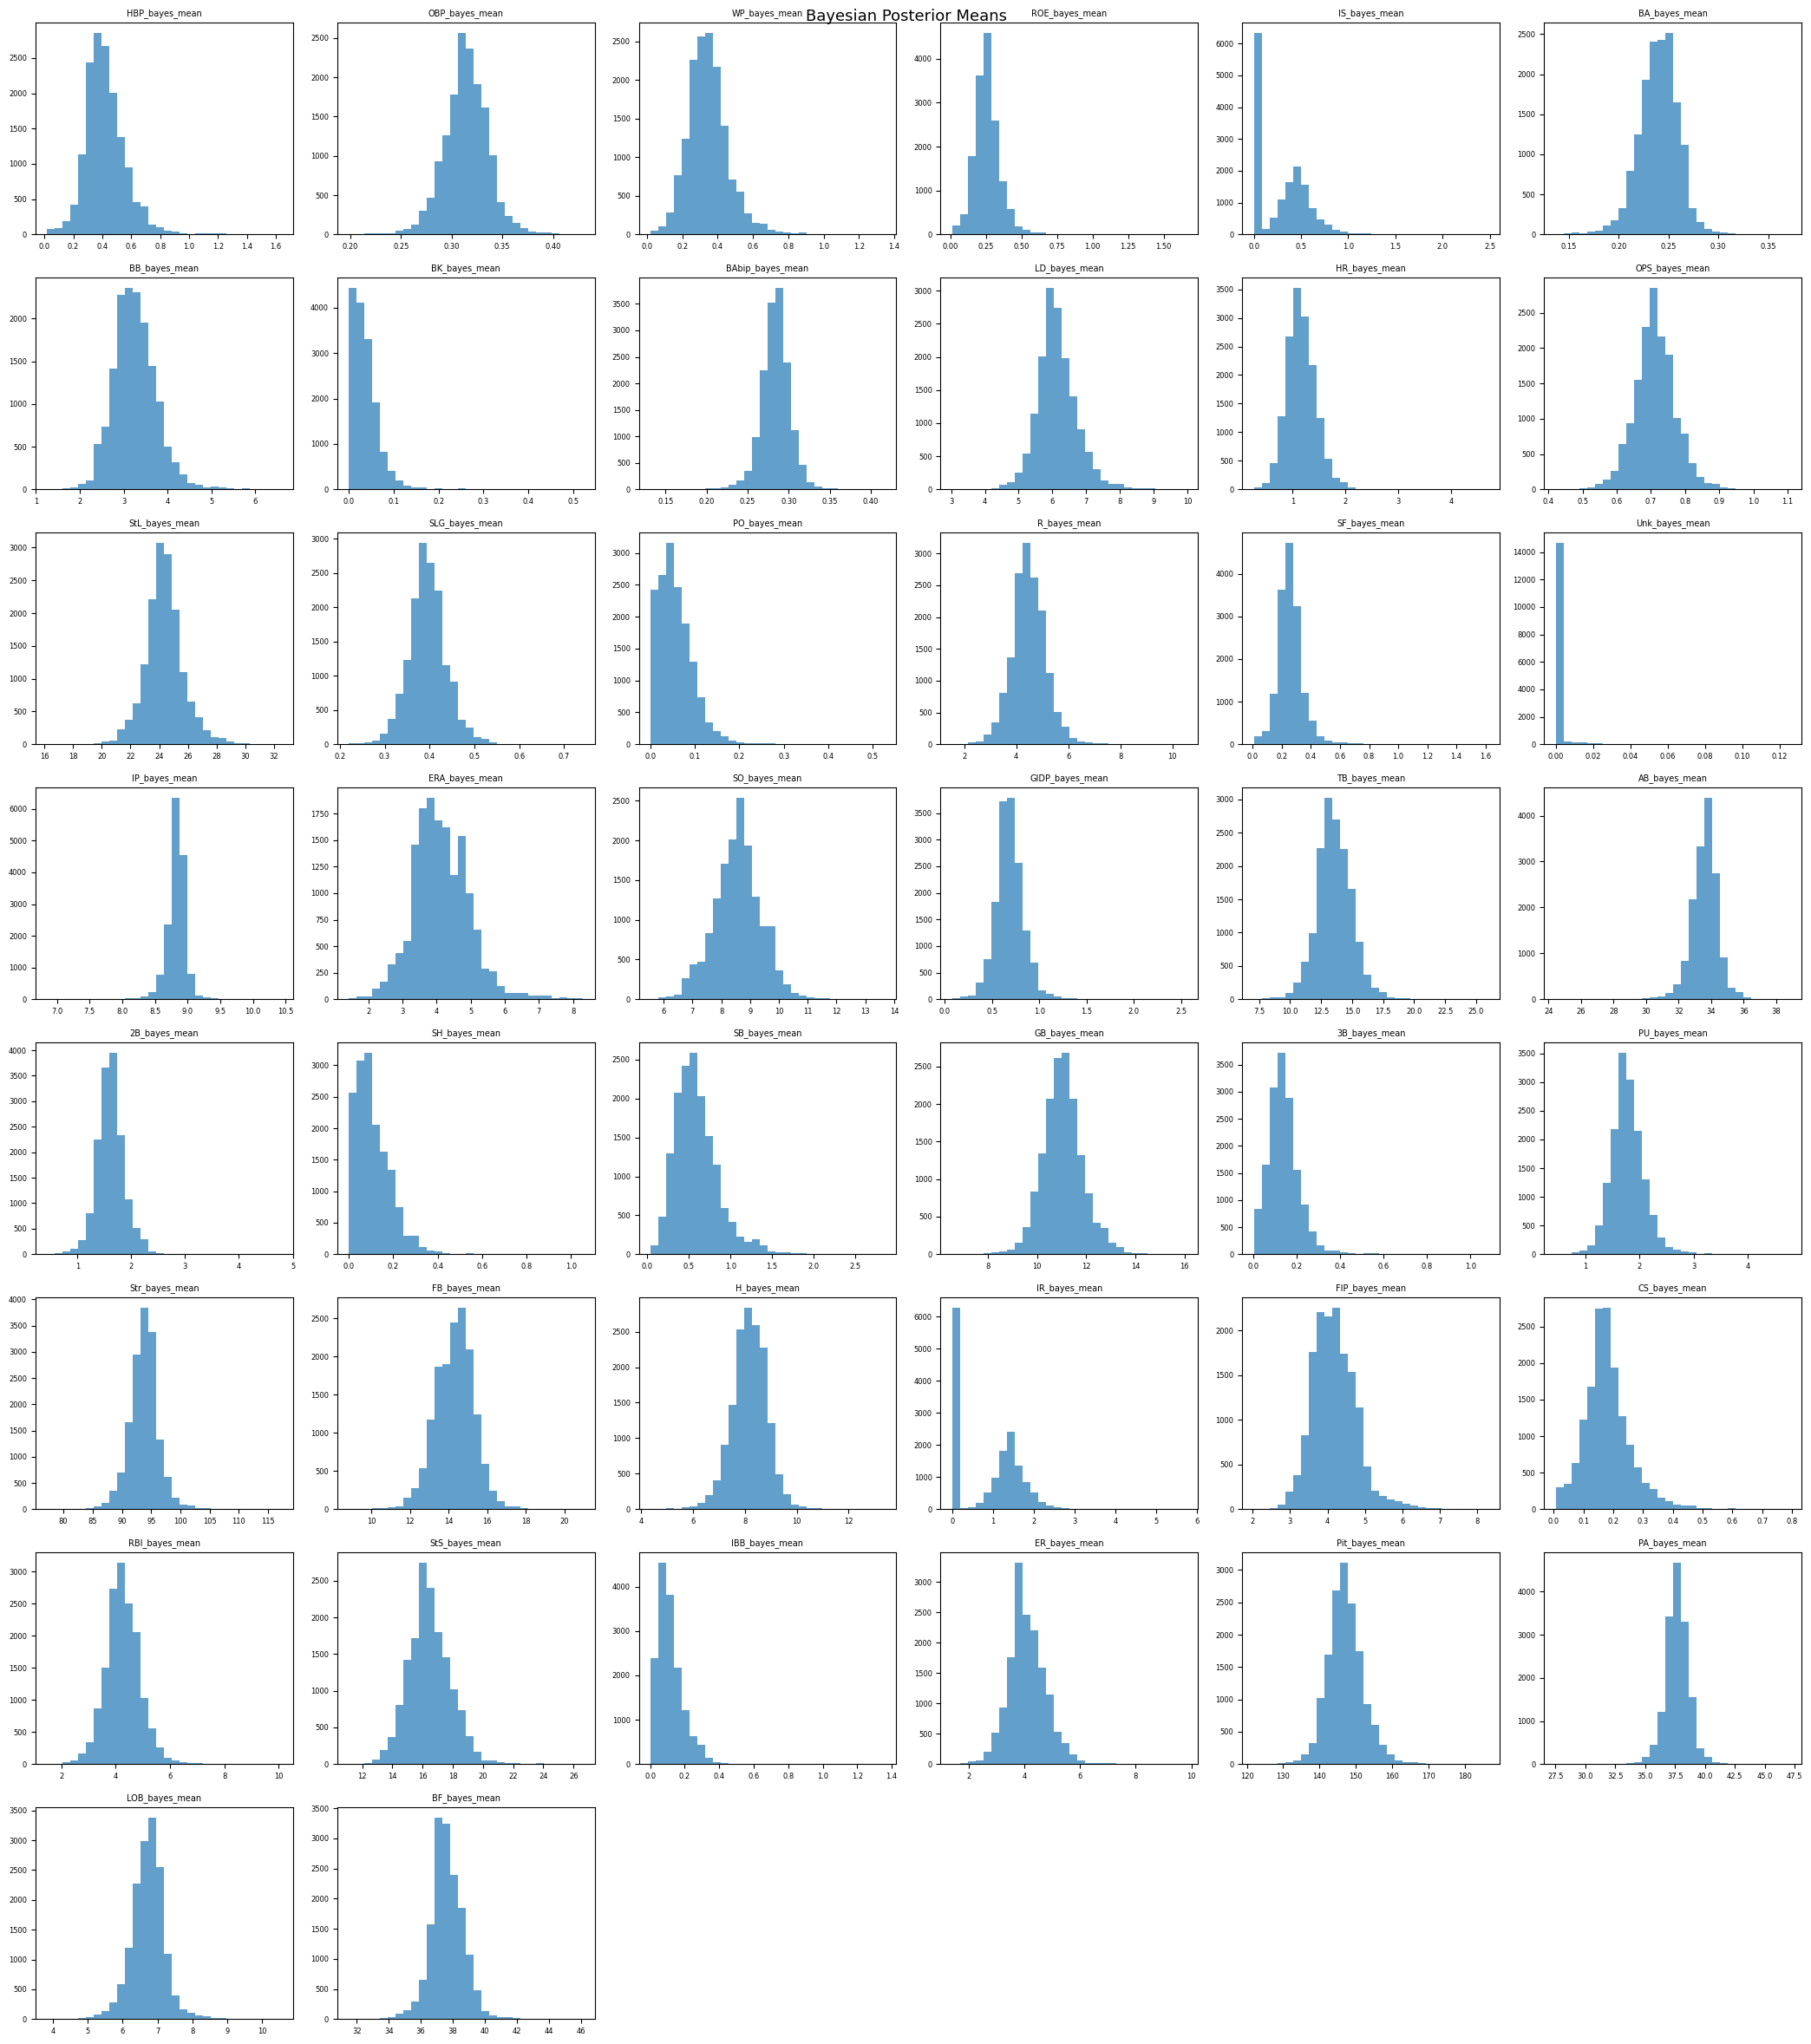

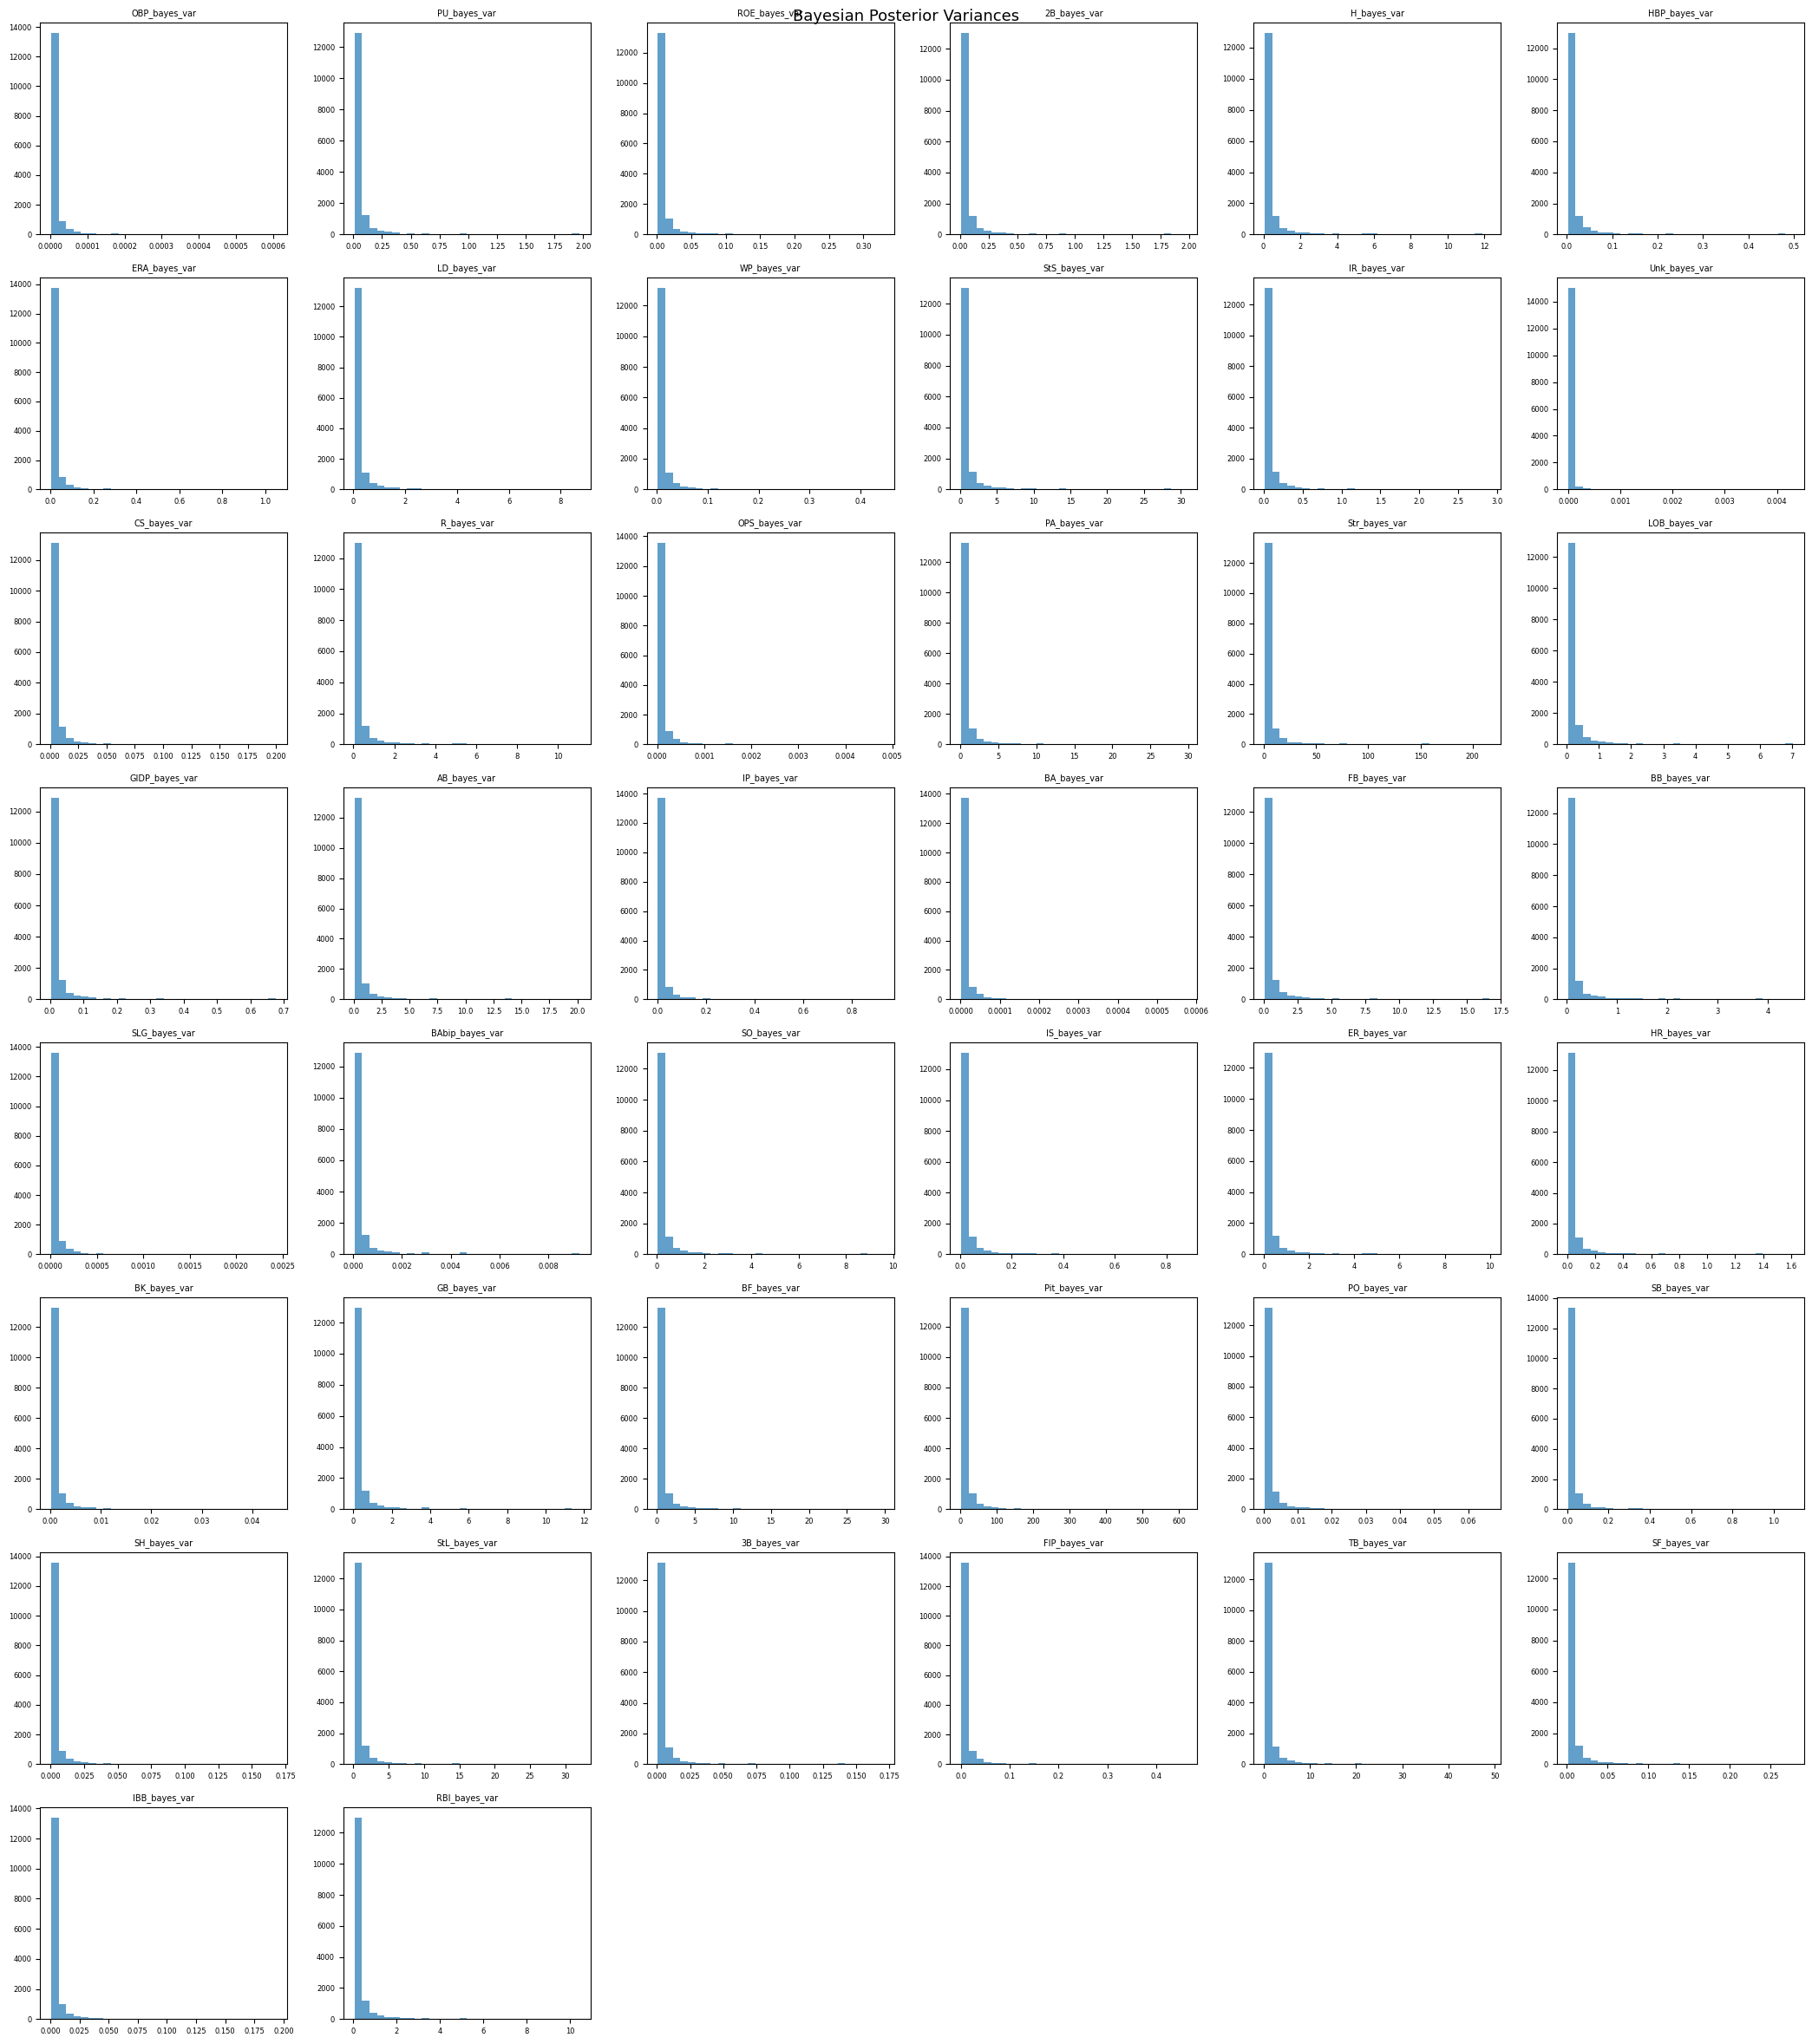

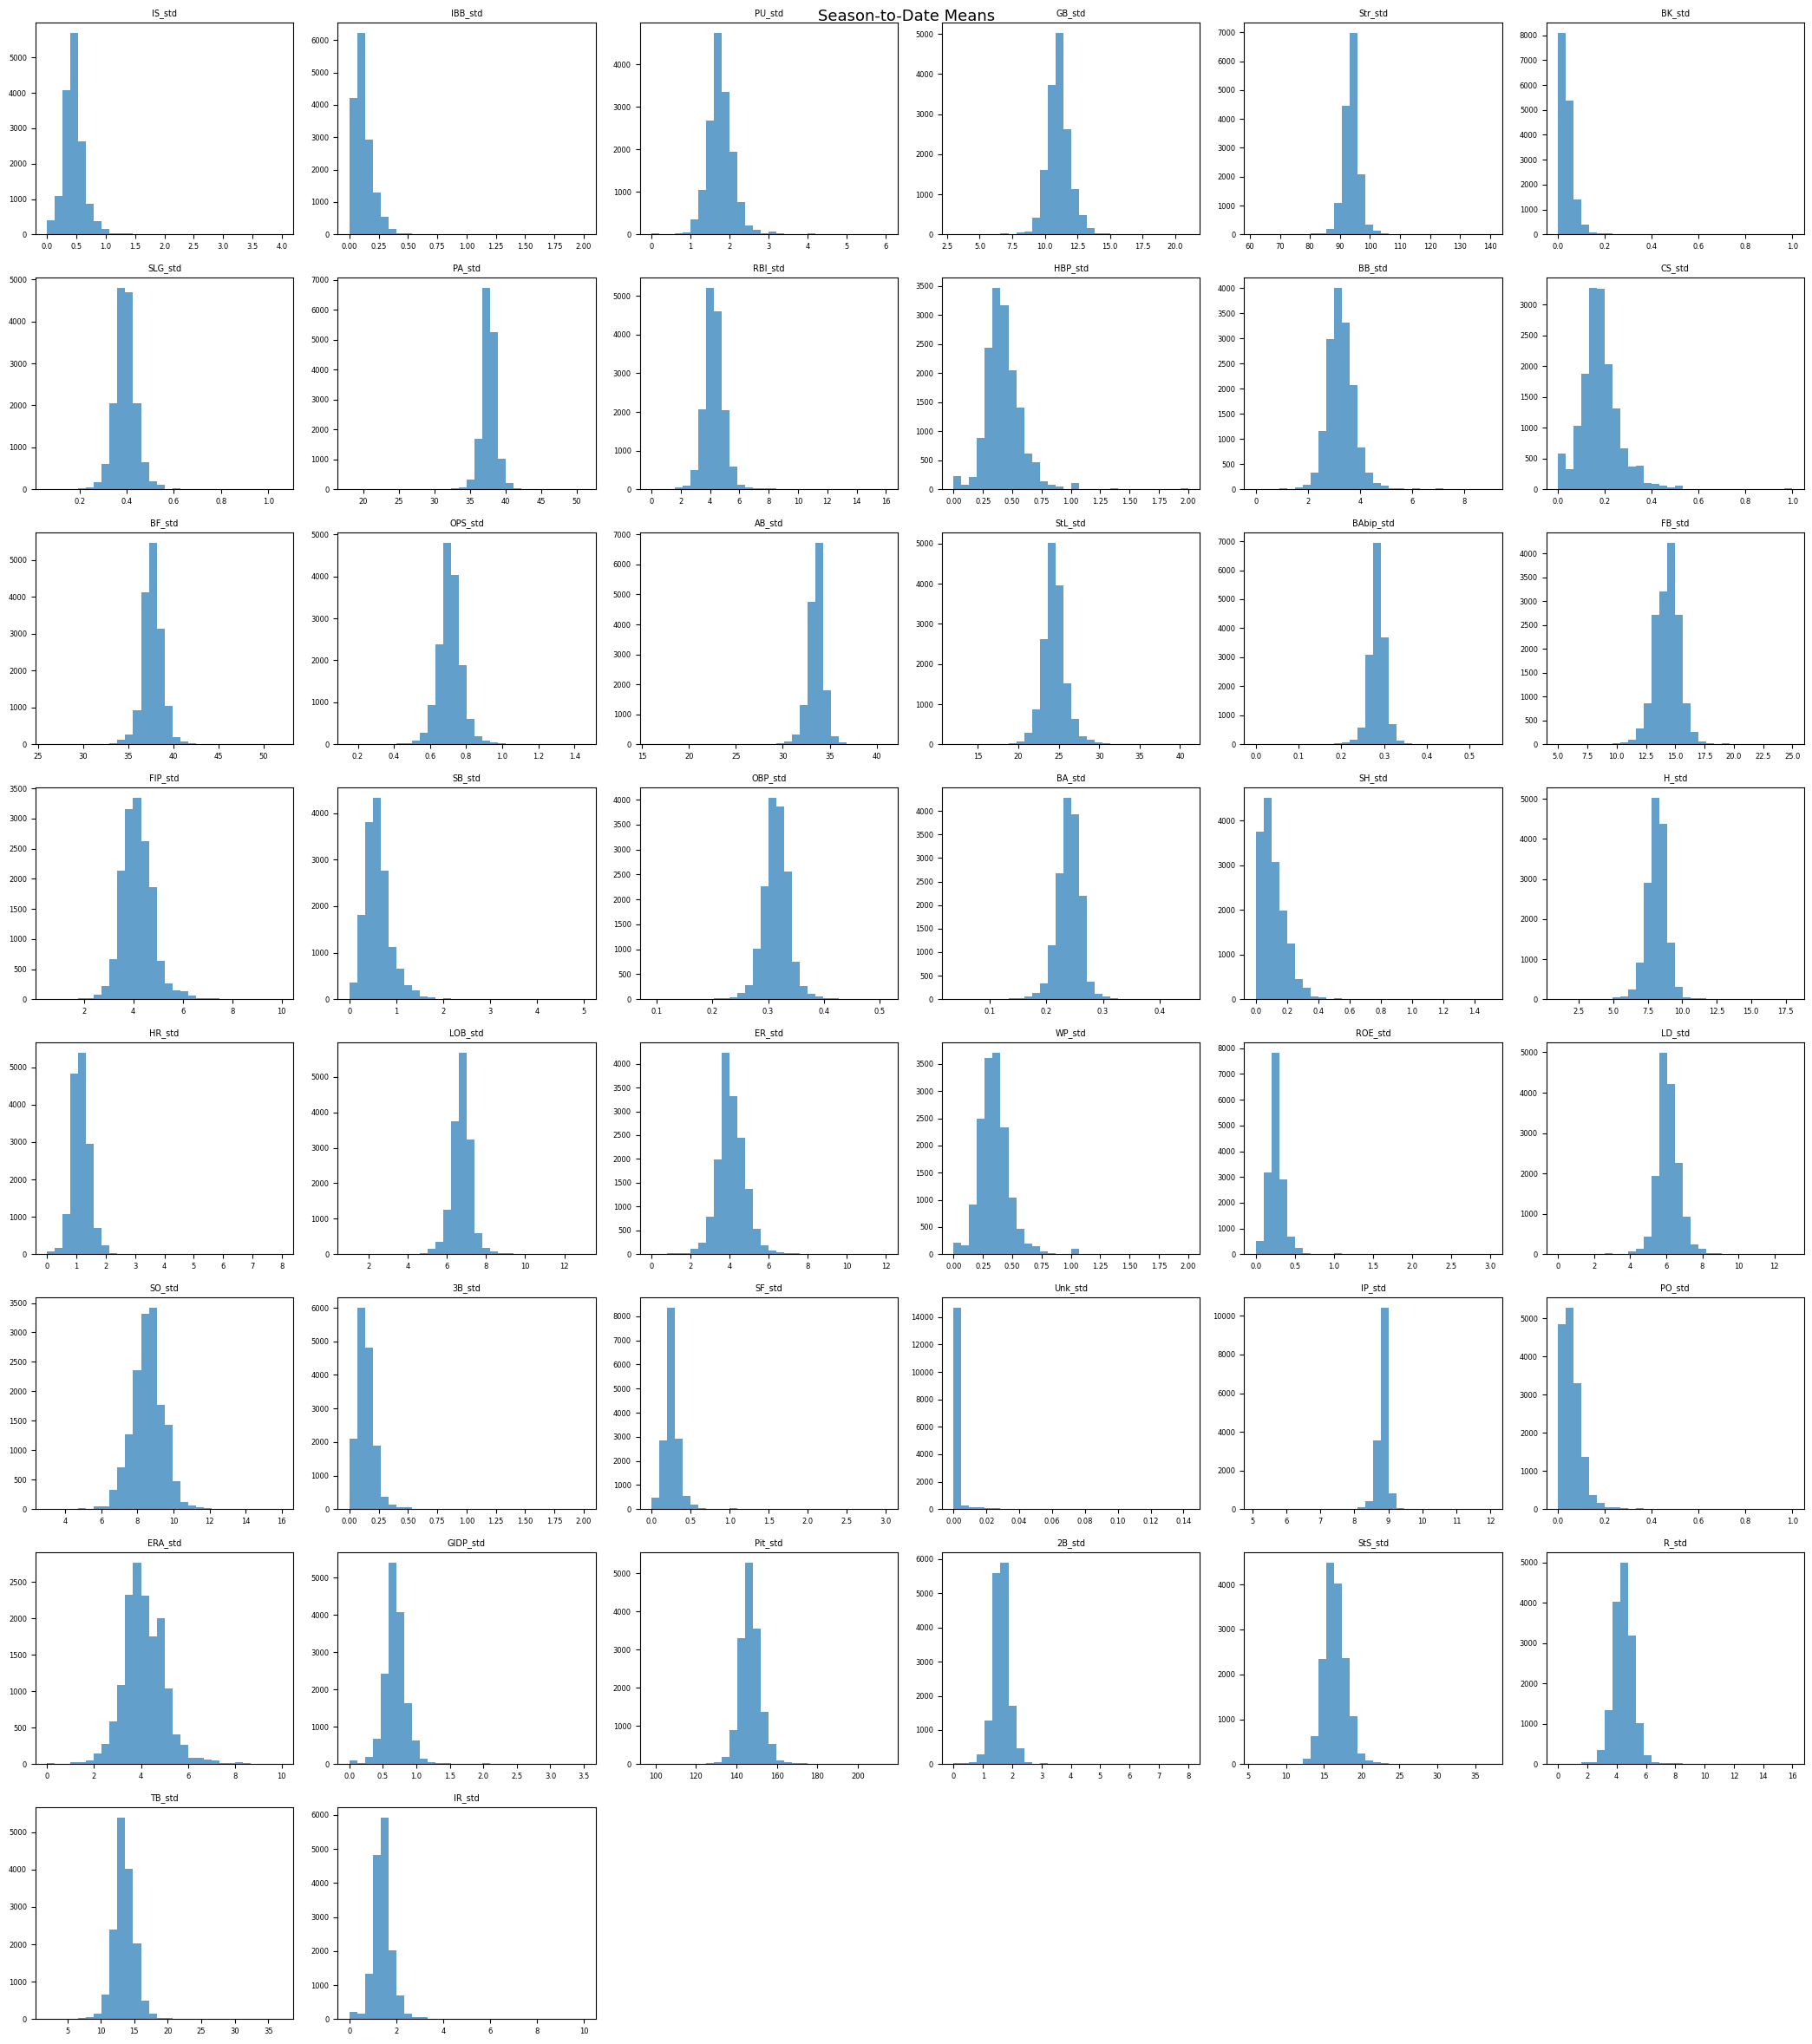

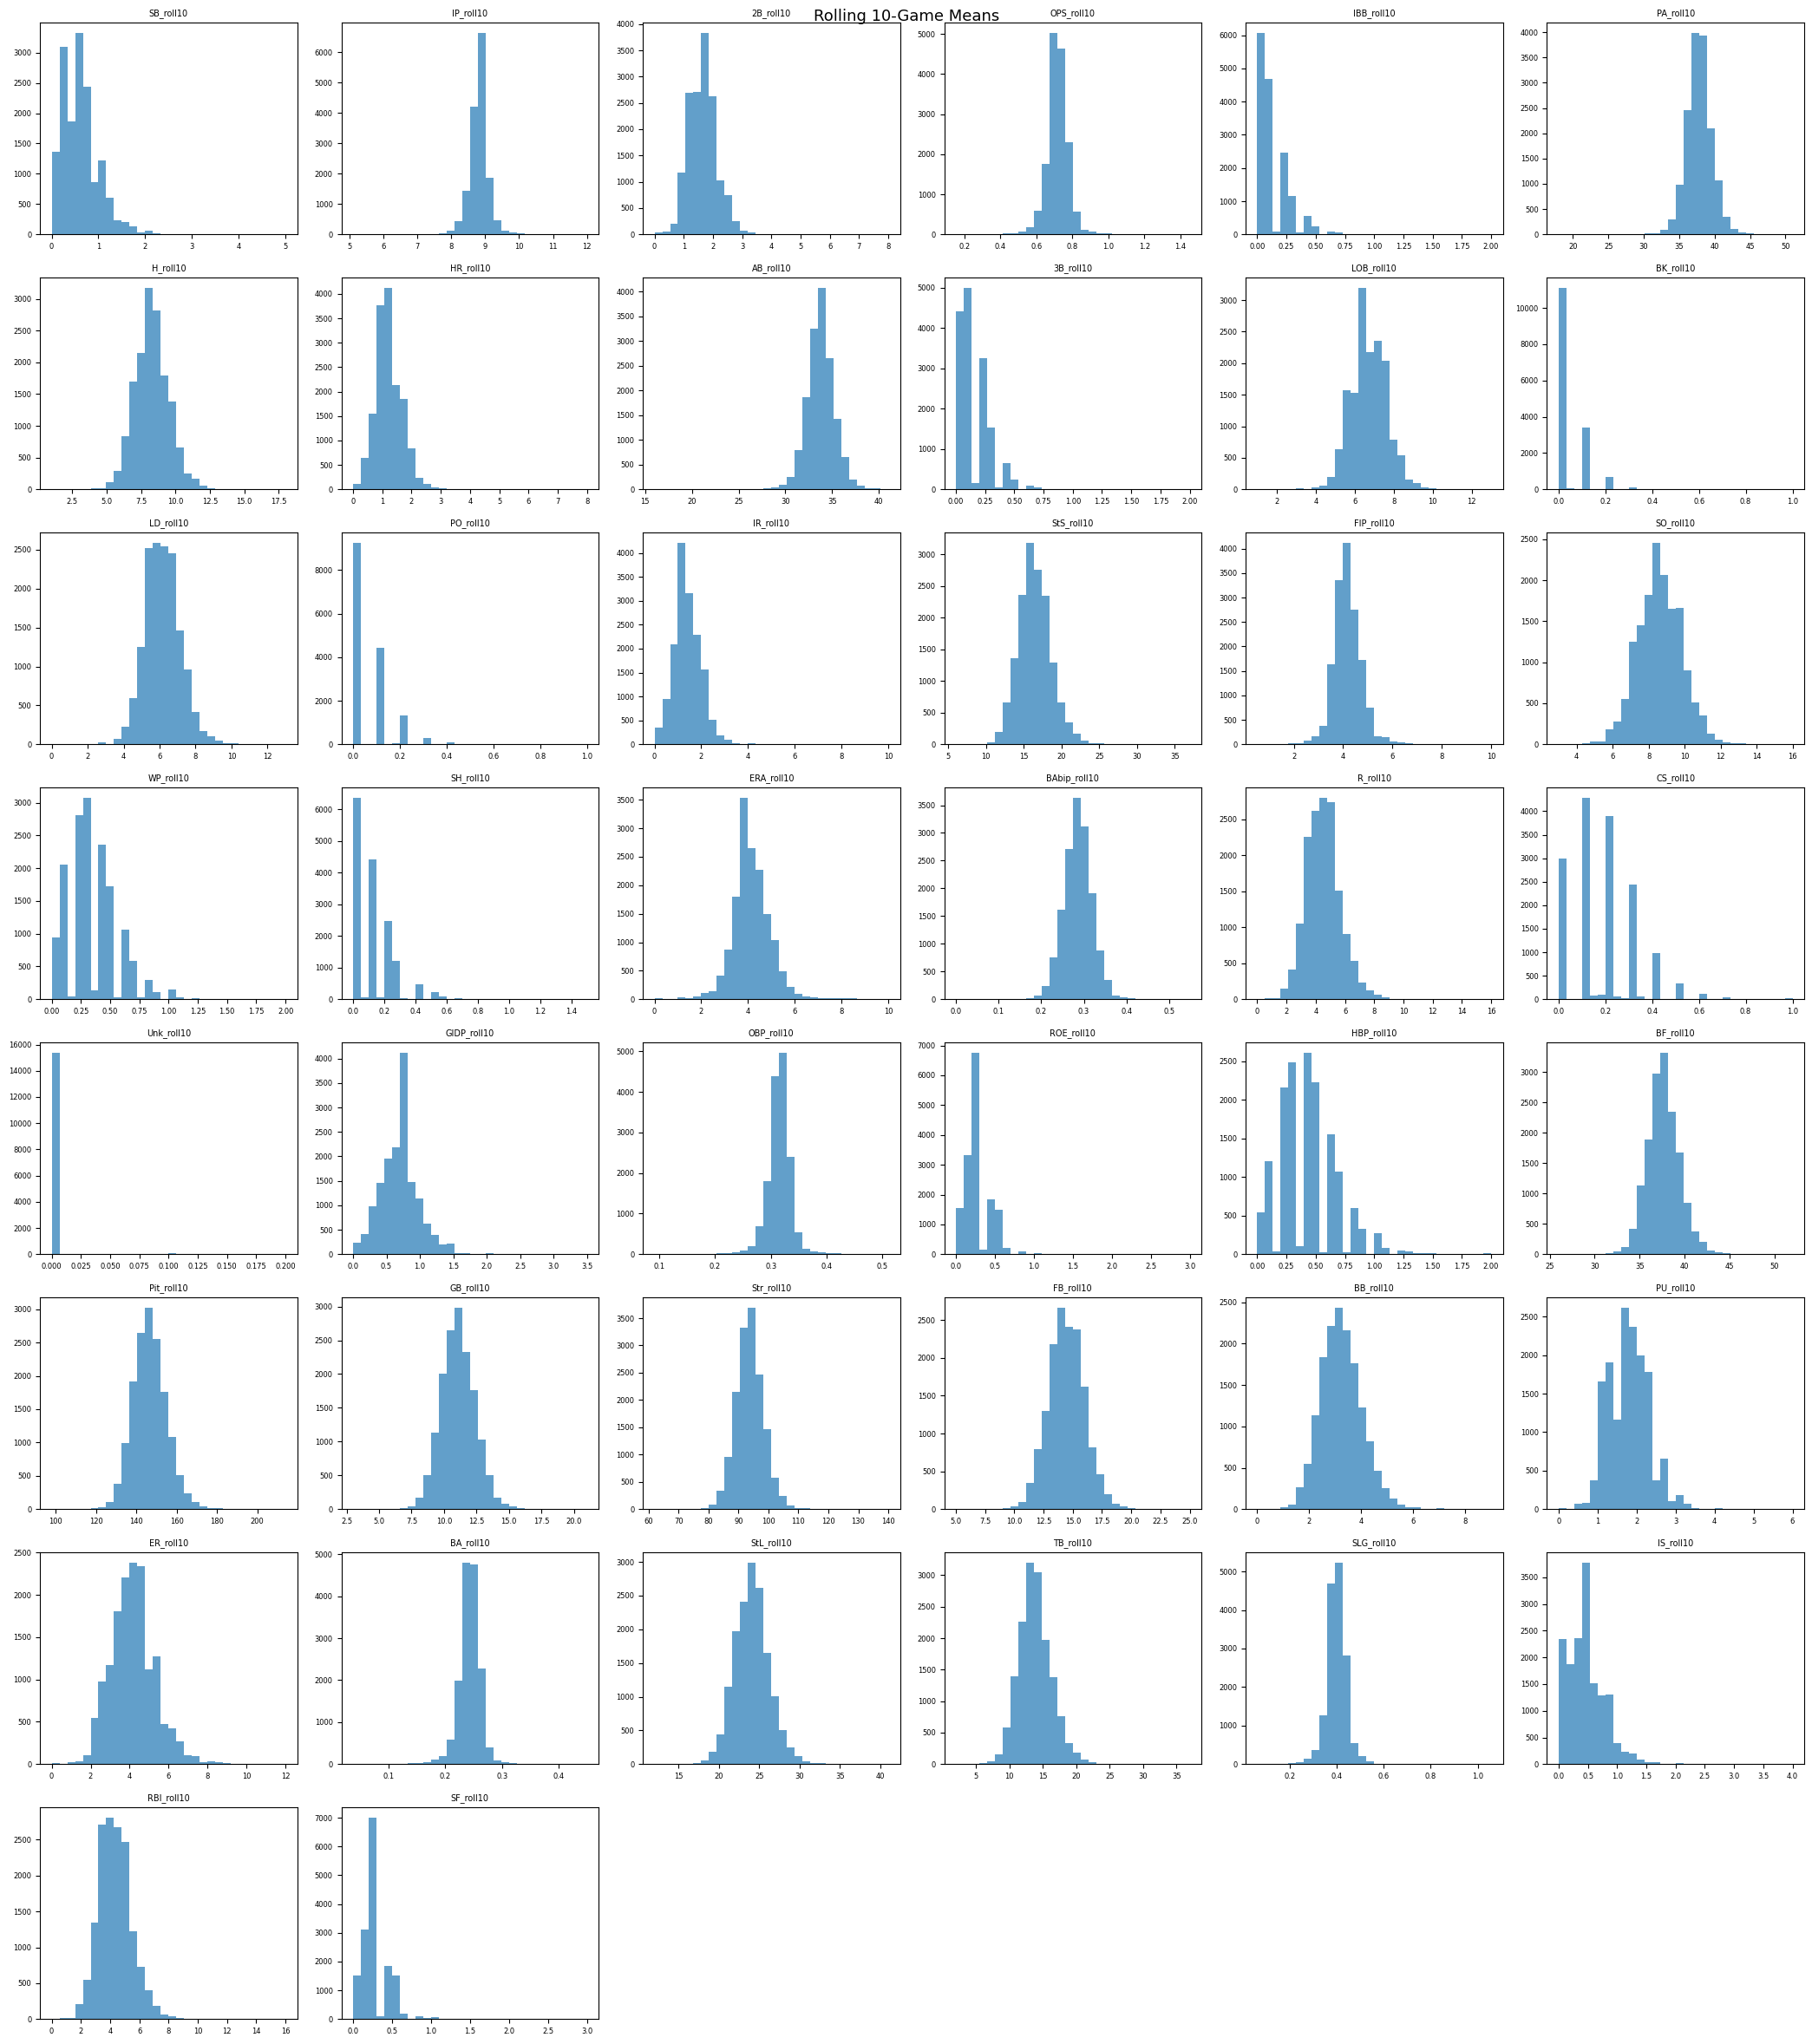

In [564]:
import math

def plot_feature_distributions(df, feature_cols, title, ncols=6):
    nrows = math.ceil(len(feature_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
    axes = axes.flatten()
    
    for i, col in enumerate(feature_cols):
        axes[i].hist(df[col].dropna(), bins=30, alpha=0.7)
        axes[i].set_title(col, fontsize=7)
        axes[i].tick_params(labelsize=6)
    
    for j in range(len(feature_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

# split by feature type
bayes_mean_cols = [c for c in X.columns if c.endswith('_bayes_mean')]
bayes_var_cols  = [c for c in X.columns if c.endswith('_bayes_var')]
std_cols        = [c for c in X.columns if c.endswith('_std')]
roll_cols       = [c for c in X.columns if c.endswith(f'_roll{WINDOW}')]

plot_feature_distributions(X, bayes_mean_cols, 'Bayesian Posterior Means')
plot_feature_distributions(X, bayes_var_cols,  'Bayesian Posterior Variances')
plot_feature_distributions(X, std_cols,        'Season-to-Date Means')
plot_feature_distributions(X, roll_cols,        f'Rolling {WINDOW}-Game Means')

## 7. Grid Search

Each parameter combination is logged as its own MLflow run under the
`mlb-game-predictor-v1` experiment. Results are sorted by CV accuracy
and `best_params` is carried forward into the final training run.


In [637]:
param_grid = {
    "model__n_estimators":  [100, 200, 300],
    "model__max_depth":     [3, 4, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample":     [0.8],
}


In [638]:
from itertools import product
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_results = []

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Running {len(combos)} combinations...")

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    # strip "model__" prefix for GradientBoostingClassifier kwargs
    model_params = {k.replace("model__", ""): v for k, v in params.items()}

    _pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            random_state=42, **model_params
        )),
    ])

    with mlflow.start_run(run_name=f"grid_{i:02d}", nested=False):
        mlflow.log_params({**model_params, "window": WINDOW,
                           "n_features": len(final_features),
                           "cv_folds": 3})

        scores = cross_val_score(_pipe, X, y, cv=cv, scoring="accuracy")

        mlflow.log_metrics({
            "cv_accuracy_mean": float(scores.mean()),
            "cv_accuracy_std":  float(scores.std()),
            **{f"cv_fold_{j+1}": float(s) for j, s in enumerate(scores)},
        })

        grid_results.append({**model_params,
                             "cv_mean": scores.mean(),
                             "cv_std":  scores.std()})

    print(f"  [{i+1}/{len(combos)}] {model_params}  cv={scores.mean():.4f} ± {scores.std():.4f}")

print("Grid search complete.")


Running 18 combinations...
  [1/18] {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8}  cv=0.5499 ± 0.0015
  [2/18] {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}  cv=0.5488 ± 0.0048
  [3/18] {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8}  cv=0.5500 ± 0.0022
  [4/18] {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8}  cv=0.5462 ± 0.0077
  [5/18] {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8}  cv=0.5448 ± 0.0037
  [6/18] {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8}  cv=0.5413 ± 0.0067
  [7/18] {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8}  cv=0.5507 ± 0.0035
  [8/18] {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}  cv=0.5439 ± 0.0036
  [9/18] {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8}  cv=0.5435 ± 0.0060
  [10

In [639]:
grid_df = pd.DataFrame(grid_results).sort_values("cv_mean", ascending=False)
grid_df


,n_estimators,max_depth,learning_rate,subsample,cv_mean,cv_std
6,200,3,0.05,0.8,0.550666,0.003505
2,100,4,0.05,0.8,0.549955,0.002155
0,100,3,0.05,0.8,0.549890,0.001537
12,300,3,0.05,0.8,0.548856,0.004458
1,100,3,0.10,0.8,0.548792,0.004805
3,100,4,0.10,0.8,0.546207,0.007718
14,300,4,0.05,0.8,0.544849,0.008430
4,100,5,0.05,0.8,0.544785,0.003651
7,200,3,0.10,0.8,0.543945,0.003558
8,200,4,0.05,0.8,0.543492,0.006049


In [640]:
best_params = grid_df.iloc[0].drop(["cv_mean", "cv_std"]).to_dict()
# cast int columns back to int
for k in ["n_estimators", "max_depth"]:
    best_params[k] = int(best_params[k])
print("Best params:", best_params)
print(f"Best CV accuracy: {grid_df.iloc[0].cv_mean:.4f} ± {grid_df.iloc[0].cv_std:.4f}")


Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8}
Best CV accuracy: 0.5507 ± 0.0035


In [641]:
# Final training run using best params from grid search
_run = mlflow.start_run(run_name="final_model")
mlflow.log_params({
    "years":          str(YEARS),
    "window":         WINDOW,
    "n_train_games":  int(len(X)),
    "n_features":     int(len(final_features)),
    "holdout_cutoff": "2026-01-01",
    **best_params,
})
print(f"Started final run: {_run.info.run_id}")


Started final run: fcf8d47da9654cf7a17ae10f877a2d32


## 7. Cross-Validation

In [642]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
        random_state=42, **best_params
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")

print(f"CV Accuracy per fold: {scores.round(3)}")
print(f"Mean: {scores.mean():.3f} +/- {scores.std():.3f}")


CV Accuracy per fold: [0.554 0.542 0.552 0.556 0.541]
Mean: 0.549 +/- 0.006


In [643]:
mlflow.log_metrics({
    "cv_accuracy_mean": float(scores.mean()),
    "cv_accuracy_std":  float(scores.std()),
    **{f"cv_fold_{i+1}": float(s) for i, s in enumerate(scores)},
})


## 8. Train Final Model

In [644]:
pipeline.fit(X, y)

train_acc = pipeline.score(X, y)
print(f"Training accuracy: {train_acc:.3f}")
print()
print(classification_report(y, pipeline.predict(X), target_names=["Away Win", "Home Win"]))

Training accuracy: 0.631

              precision    recall  f1-score   support

    Away Win       0.66      0.44      0.53      7232
    Home Win       0.62      0.80      0.70      8242

    accuracy                           0.63     15474
   macro avg       0.64      0.62      0.61     15474
weighted avg       0.64      0.63      0.62     15474



In [645]:
mlflow.log_metric("train_accuracy", float(train_acc))


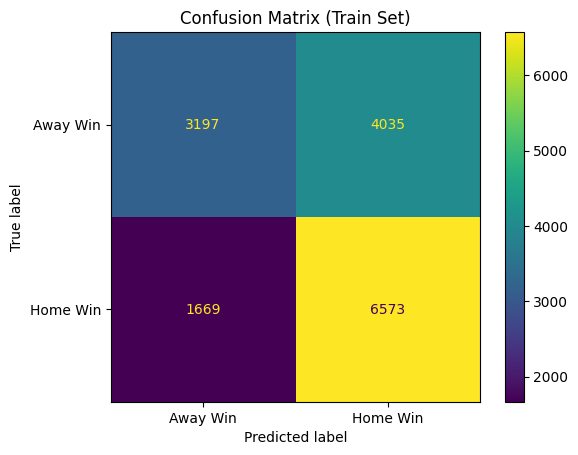

In [646]:
cm = confusion_matrix(y, pipeline.predict(X))
disp = ConfusionMatrixDisplay(cm, display_labels=["Away Win", "Home Win"])
disp.plot()
plt.title("Confusion Matrix (Train Set)")
plt.show()

## 9. Feature Importances

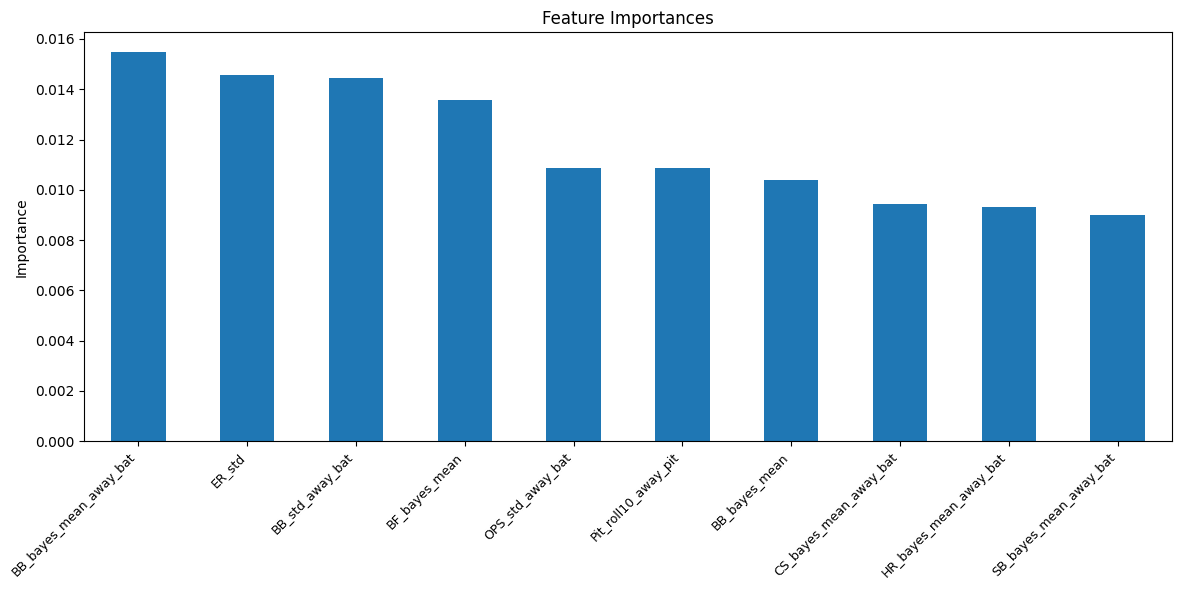

Top 10 features:
BB_bayes_mean_away_bat    0.0155
ER_std                    0.0146
BB_std_away_bat           0.0145
BF_bayes_mean             0.0136
OPS_std_away_bat          0.0109
Pit_roll10_away_pit       0.0109
BB_bayes_mean             0.0104
CS_bayes_mean_away_bat    0.0094
HR_bayes_mean_away_bat    0.0093
SB_bayes_mean_away_bat    0.0090
dtype: float64


In [660]:
importances = pipeline.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(10).plot(kind="bar")
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_imp.head(10).round(4))

## 10. Save Model

In [648]:
with open(MODEL_PATH, "wb") as f:
    pickle.dump(pipeline, f)

print(f"Model saved to {MODEL_PATH}")
print(f"File size: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

Model saved to /Users/nickchapman/pitch_predictor/backend/model/artifacts/model.pkl
File size: 298.5 KB


In [649]:
mlflow.sklearn.log_model(pipeline, "model")
mlflow.log_artifact(MODEL_PATH, "pickle")


2026/04/25 17:45:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 17:45:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## 11. Smoke Test

In [650]:
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)

prob = loaded_model.predict_proba(holdout_X)[0]
print(f"  Away win probability: {prob[0]:.3f}")
print(f"  Home win probability: {prob[1]:.3f}")


  Away win probability: 0.506
  Home win probability: 0.494


In [651]:
home_probs = pd.DataFrame(loaded_model.predict_proba(holdout_X))[1]

In [652]:
from sklearn.metrics import roc_auc_score,accuracy_score

In [653]:
roc_auc_score(holdout_y, home_probs)

0.5154573687182384

In [654]:
accuracy_score(holdout_y, home_probs>=.5)

0.5207100591715976

In [655]:
accuracy_score(holdout_y, [1 for x in holdout_y])


0.5443786982248521

In [656]:
roc_auc_score(holdout_y, [1 for x in holdout_y])

0.5

In [657]:
mlflow.log_metrics({
    "holdout_roc_auc":          float(roc_auc_score(holdout_y, home_probs)),
    "holdout_accuracy":         float(accuracy_score(holdout_y, home_probs >= 0.5)),
    "holdout_baseline_accuracy": float(accuracy_score(holdout_y, [1 for _ in holdout_y])),
    "n_holdout_games":           int(len(holdout_y)),
})
mlflow.end_run()
print(f"Run complete: {_run.info.run_id}")


Run complete: fcf8d47da9654cf7a17ae10f877a2d32


In [658]:
full_dataset[full_dataset['Date']>='2026-01-01']['home_batting_Home'].value_counts()

home_batting_Home
True    338
Name: count, dtype: int64

In [659]:
# Compare all runs
runs = mlflow.search_runs(experiment_names=["mlb-game-predictor-v1"])
runs[["run_id", "start_time", "params.years", "params.n_estimators", "params.window",
      "metrics.cv_accuracy_mean", "metrics.cv_accuracy_std",
      "metrics.train_accuracy", "metrics.holdout_roc_auc",
      "metrics.holdout_accuracy"]]\
    .sort_values("metrics.cv_accuracy_mean", ascending=False)


,run_id,start_time,params.years,params.n_estimators,params.window,metrics.cv_accuracy_mean,metrics.cv_accuracy_std,metrics.train_accuracy,metrics.holdout_roc_auc,metrics.holdout_accuracy
19,7f96c43d335f43f6af9cf1ad4397b74a,2026-04-25 19:38:28.112000+00:00,"[2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]",50,10,0.553767,0.006724,0.590151,0.487454,0.514793
12,44084516aff94663acc731811fcbcce8,2026-04-25 20:13:57.874000+00:00,None,200,10,0.550666,0.003505,NaN,NaN,NaN
16,7ea34a01afde4a7caaeb11e4aeef31b8,2026-04-25 20:01:55.276000+00:00,None,100,10,0.549955,0.002155,NaN,NaN,NaN
18,0bff85598eab4fb19140e4dc097864c3,2026-04-25 19:57:54.596000+00:00,None,100,10,0.549890,0.001537,NaN,NaN,NaN
0,fcf8d47da9654cf7a17ae10f877a2d32,2026-04-25 21:34:59.387000+00:00,"[2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]",200,10,0.549050,0.005998,0.631382,0.515457,0.520710
6,deffb23780b2436f82e417323fec53f7,2026-04-25 20:46:08.120000+00:00,None,300,10,0.548856,0.004458,NaN,NaN,NaN
17,9aad7926217248bd8d7309e074422412,2026-04-25 19:59:54.684000+00:00,None,100,10,0.548792,0.004805,NaN,NaN,NaN
15,3589c9bee1d744ccb539460e311e7b24,2026-04-25 20:04:34.974000+00:00,None,100,10,0.546207,0.007718,NaN,NaN,NaN
4,4d9d7f2442074279ba807601879fd5c5,2026-04-25 20:58:18.758000+00:00,None,300,10,0.544849,0.008430,NaN,NaN,NaN
14,1a15c09c398545dbbe3cc62a82231bf9,2026-04-25 20:07:15.804000+00:00,None,100,10,0.544785,0.003651,NaN,NaN,NaN
